## 캐글 프로젝트 01: 타이타닉 생존 예측(Titanic Survivor Prediction From Kaggle)

# 프로젝트 Overview
본 프로젝트의 목표는 캐글 제공의 타이타닉 데이터 세트를 분석하고 데이터 구조에 적합한 머신러닝 모델을 설계 및 학습, 이를 통해 
'탑승객의 생존'을 예측하는 데에 있다.

이에 따라 본 프로젝트는 다음의 순서로 진행된다: 



## 프로젝트 진행 순서

1. 데이터 구조 파악
   - shape, columns, info, describe, 결측치, 고유값 확인

2. EDA 및 피쳐-타깃 관계분석
   - 피쳐-타깃 관계 분석
   - 변수 간 관계 분석
   - 파생변수 후보 검토

3. 파생변수 생성 및 검토
   - 원본 피쳐 유지 여부 결정
   - 파생변수 사용 여부 결정

4. 데이터 전처리
   - 결측값 처리
   - 이상값 처리
   - 중복값 확인
   - 파생변수 생성
   - 범주형 인코딩
   - 수치형 스케일링 여부 결정

5. 피쳐 선정

6. 인코딩 및 표준화 처리

7. Baseline 설정 및 모델별 성능 비교
   - 전체 사망 예측과 성별 기반 예측을 basline 및 목표로 설정
   - 총 11개의 주요 분류 모델 교차 검증 성능 비교

8. 하이퍼파라미터 튜닝
   - 성능 우수 모델 3가지 대상 튜닝

9. 실험 파생변수 설계
   - 타이타닉 구조 당시 현실 상황 반영해 변수 추가 생성
   - 기존 모델과 성능 비교

10. 최종 모델 성능 비교
   - 실험 변수 적용 모델이 Train Set에서 성능 소폭 개선 확인

11. Kaggle 제출

12. 결과정리
   - 변수 선택 기준
   - 전처리 방법
   - 성능 개선 과정
   - 피드백

# 주요 라이브러리 import

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier



# Dataset 준비

In [3]:
train = pd.read_csv(r'C:\project\kaggle_project\practice\data\train.csv')
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# 데이터 구조 파악
: 데이터셋의 구조, 크기, 특징 등을 파악



분석결과
- Titanic train 데이터는 총 891개 행과 12개 변수로 구성됨
- 타깃 변수는 `Survived`이며, `0 = No`, `1 = Yes`로 코딩됨
  - 즉, `0 = 생존하지 않음`, `1 = 생존함`으로 해석됨
- 전체 생존율은 약 38.4%, 사망 비율은 약 61.6%로 클래스 불균형이 다소 존재함
- `PassengerId`는 식별자 변수로 제거 후보이며, `Name`은 `Title` 등으로 가공 필요함
- 수치형 변수는 `Age`, `Fare`, 범주형 변수는 `Pclass`, `Sex`, `SibSp`, `Parch`, `Embarked`로 분류됨
- `Ticket` 680개, `Cabin` 146개로 고유값이 많아 별도 변환 필요함
- 결측치는 `Age` 177개, `Cabin` 687개, `Embarked` 2개로 확인됨
- `Embarked`는 최빈값 대체, `Age`는 그룹별 중앙값 대체, `Cabin`은 결측 여부 변수 또는 첫 글자 추출 검토 필요함

In [4]:
import numpy as np
import pandas as pd

print("shape")
print(train.shape)
print('='*100)

print("columns")
print(train.columns)
print('='*100)

print("describe")
print(train.describe())
print('-'*100)
print(train.describe(exclude='number'))
print('='*100)

print("info")
print(train.info())
print('='*100)

print("dtypes")
print(train.dtypes)
print('='*100)

# 변수 타입 확인
num_cols = [x for x in train.columns if (train[x].nunique()>=20 and (train[x].dtypes == 'int' or train[x].dtypes == 'float'))]
cat_cols = [y for y in train.columns if y not in num_cols]
print(f'num_columns: {num_cols}', f'\ncat_cols: {cat_cols}')

shape
(891, 12)
columns
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
describe
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.

# 피쳐-타깃 변수 관계 분석
: 주요 피쳐와 타깃 변수 `Survived` 간의 관계를 확인하고, 예측에 사용할 후보 변수를 선별함

분석결과
- `Pclass`는 등급이 높을수록 생존율이 높게 나타나며, 생존 예측에 중요한 변수로 판단됨
- `Sex`는 여성의 생존율이 남성보다 크게 높아, 가장 강한 예측 변수 중 하나로 확인됨
- `SibSp`, `Parch`는 단독으로는 명확한 선형관계가 약하나, 가족 동반 여부와 관련된 정보가 있어 `Fam`, `Alone` 파생변수 생성이 타당함
- `Fam` 분석 결과, 혼자 탑승한 경우보다 가족과 함께 탑승한 경우 생존율이 높게 나타남
- `Alone` 변수는 단독 탑승자의 생존율이 상대적으로 낮아 유의미한 파생변수 후보로 판단됨
- `Cabin`은 결측 여부에 따라 생존율 차이가 크게 나타났으며, `Cabin_na`는 예측에 유의미한 변수로 판단됨
- `Cabin_na`는 `Pclass`와 밀접한 관련이 있어, 단순 결측치가 아니라 좌석 등급 및 승객 지위 정보를 반영할 가능성이 있음
- `CabinFirstLetter`중 일부 알파벳은 생존비중과 밀접한 관련성을 보였음
- `Name`에서는 `Title`과 `NameLength`를 파생변수로 생성함
- `Title`은 성별, 연령, 결혼 여부, 사회적 지위 정보를 반영하며, `Mr`, `Mrs`, `Miss`, `Master` 간 생존율 차이가 뚜렷함
- `NameLength`는 길이가 길수록 생존율이 높아지는 경향을 보이나, 직접적 원인보다는 신분 정보가 간접 반영된 변수로 해석됨
- `Embarked`는 `C`에서 생존율이 상대적으로 높게 나타났으나, 이는 승선항 자체의 효과라기보다 `Pclass`, `Fare`, `Sex` 등 다른 변수와의 상관성 때문일 가능성이 있음
- `Ticket`은 문자 포함 여부만으로는 생존율 차이가 크지 않았으나, 티켓 숫자 첫 자리와 문자 접두어는 생존율 차이를 보임
- `TicketDigitFirst`는 숫자가 낮을수록 생존율이 높아지는 경향이 있으며, 표본 수가 적은 값은 `Other`로 통합함
- `TicketOnlyAlpha`는 `PC`, `SC` 등 일부 접두어에서 생존율이 높고, `A`, `CA`, `SOTON` 등에서는 낮게 나타나 예측 후보 변수로 판단됨
- `Age`는 특정 구간, 특히 유아층과 고령층에서 생존율 차이가 나타나며, 구간화 변수로 활용 가능함
- `Age_na`에서 `Age`가 결측일 수록 생존율 낮아짐. `Age`의 결측으로 인한 정보손실 보완 파생변수로 결정.
- `Fare`는 운임이 높을수록 생존율이 높아지는 경향이 있어 주요 수치형 예측 변수로 판단됨

#### 최종 사용 피쳐
- 최종적으로 `Pclass`, `Sex`, `Age`, `Fare`, `Embarked`, `Fam`, `Alone`, `Cabin_na`, `Age_na`, `Title`, `NameLength`, `TicketDigitFirst`, `TicketOnlyAlpha`, `CabinFirstLetter`를 주요 후보 피쳐로 사용함

In [5]:
# 범주형 피쳐 속성값 특징 확인
    # name - unique 891개로 많음 -> 특성값 변환 필요, mr. mrs. miss 등 성별 혹은 직위를 확인할 수 있는 단서 확인
    # SibSp, Parch: 다수 레코드 0-2 확인, 이후는 데이터 수 부족. 두 변수 각각의 타깃 연관성 분석 후 family_count라는 별도의 파생변수 생성 고려
    # Ticket: 숫자형, 문자형, 숫자+문자 혼합형 발견. Ticket은 승객의 사회경제적 지위, 생존율 높은 좌석의 단서를 제공할 수 있으므로 파생변수 생성 고려
    # Cabin: 문자형+숫자형 조합 -> 추가 확인 필요. 선실 번호를 문자 / 숫자로 나누어 파생변수 생성시 생존율 단서 제공 여지 있으므로 파생변수 생성 고려
for col in cat_cols:
    print(f'<{col}>')
    print(train[col].nunique())
    print(train[col].value_counts().sort_index())
    print("-"*100)


<Survived>
2
Survived
0    549
1    342
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
<Pclass>
3
Pclass
1    216
2    184
3    491
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
<Name>
891
Name
Abbing, Mr. Anthony                      1
Abbott, Mr. Rossmore Edward              1
Abbott, Mrs. Stanton (Rosa Hunt)         1
Abelson, Mr. Samuel                      1
Abelson, Mrs. Samuel (Hannah Wizosky)    1
                                        ..
de Mulder, Mr. Theodore                  1
de Pelsmaeker, Mr. Alfons                1
del Carlo, Mr. Sebastiano                1
van Billiard, Mr. Austin Blyler          1
van Melkebeke, Mr. Philemon              1
Name: count, Length: 891, dtype: int64
----------------------------------------------------------------------------------------------------
<Sex>
2
Sex
female    314
male  

In [6]:
# 범주형 피쳐 - 타깃 관계 분석
    # Pclass: Pclass가 작을 수록(좌석 등급이 높을 수록) 생존 비율이 높음. 예측 영향 주요 후보변수
    # Sex: 여성의 경우 생존 비율이 남성에 비해. 예측 영향 주요 후보변수
    # SibSp: 혼자일 경우 생존확률이 상대적으로 떨어지나 단순 선형관계는 아님. 다만 >=2 부터 count 부족하여 신뢰할 수 없음 -> 별도의 추가 조치 필요?
    # Parch: SibSp와 유사한 관계보임. 다만 >=3부터 count 부족으로 신뢰할 수 없음
    # Embarked: 특이하게도 승선항구 = C(Cherbourg)일 때 생존확률이 약 17-22% 높음. 승선항구와 타 변수와의 상관관계 분석 필요. (승선항구 자체로는 생존과 합리적 연관성을 찾기 어려우나, 다른 변수와 상관성 있을 가능성)
print("="*100)
for col in ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']: # 타깃, 고유값, 결측치 많은 변수 제외
    print(f'{col} x Survived')
    display(
        train.groupby(by=col, dropna=False)['Survived']
            .agg(['count', 'mean']))
    
    print('-'*100)

Pclass x Survived


,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


----------------------------------------------------------------------------------------------------
Sex x Survived


,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


----------------------------------------------------------------------------------------------------
SibSp x Survived


...

----------------------------------------------------------------------------------------------------
Parch x Survived


,count,mean
Parch,,
0,678,0.343658
1,118,0.550847
2,80,0.500000
3,5,0.600000
4,4,0.000000
5,5,0.200000
6,1,0.000000


----------------------------------------------------------------------------------------------------
Embarked x Survived


,count,mean
Embarked,,
C,168,0.553571
Q,77,0.389610
S,644,0.336957
NaN,2,1.000000


----------------------------------------------------------------------------------------------------


In [7]:
# 파생변수 1 (family_count) 분석
    # 혼자일 때 보다 가족과 함께 (2-4) 탑승시 생존 비율이 높음
    # 5 이상의 경우 데이터 수 부족으로 섣부른 판단할 수 없음
train["Fam"] = train["SibSp"] + train["Parch"] + 1
fam = train.groupby(by="Fam", dropna=False)["Survived"].agg(['count', 'mean'])
display(fam)
print('-'*100)

# 파생변수 2 (alone) 분석
    # 솔로 탑승 경우 그렇지 않은 경우에 비해 생존비율이 낮다는 점에 착안, 솔로 탑승 여부를 파생 변수 추가로 생성
    # 솔로 탑승은 그렇지 않은 경우보다 약 20% 생존 비율이 낮음을 확인
train["Alone"] = (train["Fam"] == 1).astype('int')
alone_t =train.groupby(by='Alone')["Survived"].agg(["count", "mean"])
display(alone_t)
print('-'*100)

# 파생변수 3(na_Cabin) 분석
    # Cabin이 결측인 경우, 생존하지 못해 사후 좌석 조사가 이루어지지 않았거나 우대 고객이 아닐 가능성을 고려해 Cabin 결측 여부(=1 NaN)로 파생변수 추가 생성
    # 결측인 경우 비결측에 비해 생존 비율 2배 낮음 (유의미한 예측 후보 파생변수)
    # 특히 na_Cabin은 Pclass와 밀접한 관련성을 지닌 것으로 확인(1등석에서 Cabin 결측율 10배 낮음) -> 추후 결측치 처리에 Pclass를 참고 변수로 사용 가능
train["Cabin_na"] = train["Cabin"].isna().astype('int') 
cabin_na_t = train.groupby(by="Cabin_na")["Survived"].agg(["count", "mean"])
display(cabin_na_t)
print('-'*100)
display(pd.crosstab(train["Pclass"], train["Cabin_na"]))
display(train.groupby(by=["Pclass", "Cabin_na"])["Survived"].agg(["count", "mean"]))

# 파생변수 4(Title, NameLength) 분석
    # NameLength를 파생 변수로 생성. 기혼 여부, 별명, 상류층 middle name 등 개인 신상 정보 반영
    # Title 파생변수 생성. 이름 중 ,와 . 사이의 단어가 개인 신상(기혼여부, 남성/여성, 아이, 직업) 표현 -
    # NameLength가 길 수록 생존 비율이 높은 양의 선형관계를 보임. 다만, 이름 길이가 원인이 아닌 승객의 개인적 정보가 반영된 변수일 가능성 높음
    # Miss, Mrs 여성 Title은 Mr 남성 Title에 비해 생존 비중이 높음
    # Sex와 분리하여 생존비율 확인 결과 여성 중에서도 Mrs(기혼)이 상대적 생존 비중 높음, 남성 중 Master(아이)의 생존 비중이 5배 높음
    # NameLength를 후보변수로, Title을 예측 성능 주요 변수 후보로 설정
train["NameLength"] = train["Name"].str.len()
train["NameLengthBin"] = pd.qcut(
    train["NameLength"], 
    q=5, 
    duplicates="drop")
name_length_t = train.groupby("NameLengthBin")["Survived"].agg(["count", "mean"])
display(name_length_t)

train["Title"] = train["Name"].str.extract(r",\s*([^\.]+)\.", expand=False)
print(train["Title"].value_counts())

train["Title"].replace({"Mile": "Miss", 
                        "Ms": "Miss", 
                        "Mme": "Mrs"})

train["Title"] = train["Title"].replace({
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs"
})

rare_titles = [
    "Dr", "Rev", "Major", "Col", "Capt",
    "Lady", "Don", "Jonkheer", "Sir", "the Countess"
]
train["Title"] = train["Title"].replace(rare_titles, "Rare")
title_t = train.groupby("Title")["Survived"].agg(["count", "mean"])
display(title_t)

sex_title_t = train.groupby(by=["Sex", 'Title'], dropna=False)["Survived"].agg(["count", "mean"])
display(sex_title_t)

for col in ['Pclass', 'Sex', 'Title']:
    print(f"{col} X Embarked")
    display(train.groupby(by=[col, "Embarked"])["Survived"].agg(["count", "mean"]))
    result1 = pd.crosstab(train["Embarked"], train[col]).astype('str')
    result2 = (pd.crosstab(train["Embarked"], train[col], normalize='index').round(2)).astype('str')
    display(result1 + "(" + result2 + ")")
    
print("\n[Embarked별 Fare 분포]")
display(
    train.groupby("Embarked", dropna=False)["Fare"]
         .agg(["count", "mean", "median", "min", "max"])
)

# 파생변수 5(CabinFirstLetter)
    # Cabin의 경우 문자+숫자, 숫자, 문자 등 조합의 속성값 구성
    # 문자/숫자를 분리하여 분석할 필요있음
    # 숫자의 경우 생존율에 별다른 차이를 보이지 않았으나
    # 문자 첫글자 중 일부는 생존율과 밀접한 관련성을 보임
    # B, D, E 생존율 상대적으로 높음
    # CabinNumber의 경우 고른 분포로 관련성 적음
    # CabinFirstLetter을 파생변수로 설정, count 적은 속성값은 일괄 묶음 처리

# CabinFirstLetter
train["CabinFirstLetter"] = train["Cabin"].astype("string").str[0].fillna("Missing")

display(
    train.groupby("CabinFirstLetter", dropna=False)["Survived"]
         .agg(["count", "mean"])
         .sort_values("mean")
)

# CabinNumber
train["CabinNumber"] = (
    train["Cabin"]
    .astype("string")
    .str.extract(r"(\d+)", expand=False)
)

train["CabinNumber"] = pd.to_numeric(train["CabinNumber"], errors="coerce")

display(
    train.groupby(pd.qcut(train["CabinNumber"], 5, duplicates="drop"))["Survived"]
         .agg(["count", "mean"])
)

    # CabinNumber 표본 수 작은 값 그룹핑
cn_gr = train["CabinFirstLetter"].value_counts()

cn_gr_idx = cn_gr\
    [
        (cn_gr <= 30) 
     & (cn_gr.index != 'Missing')
     ].index
    
train["CabinFirstLetter"] = \
    train["CabinFirstLetter"]\
        .replace(cn_gr_idx, "Other")
        
display(train["CabinFirstLetter"].value_counts())



,count,mean
Fam,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


----------------------------------------------------------------------------------------------------


,count,mean
Alone,,
0,354,0.505650
1,537,0.303538


----------------------------------------------------------------------------------------------------


,count,mean
Cabin_na,,
0,204,0.666667
1,687,0.299854


...

,count,mean,median,min,max
Embarked,,,,,
C,168,59.954144,29.70,4.0125,512.3292
Q,77,13.276030,7.75,6.7500,90.0000
S,644,27.079812,13.00,0.0000,263.0000
NaN,2,80.000000,80.00,80.0000,80.0000


,count,mean
CabinFirstLetter,,
T,1,0.000000
Missing,687,0.299854
A,15,0.466667
G,4,0.500000
C,59,0.593220
F,13,0.615385
B,47,0.744681
E,32,0.750000
D,33,0.757576


C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4273727422.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(pd.qcut(train["CabinNumber"], 5, duplicates="drop"))["Survived"]


,count,mean
CabinNumber,,
"(1.999, 19.8]",40,0.725000
"(19.8, 33.0]",41,0.682927
"(33.0, 51.0]",40,0.675000
"(51.0, 85.2]",39,0.615385
"(85.2, 148.0]",40,0.650000


CabinFirstLetter
Missing    687
C           59
B           47
Other       33
D           33
E           32
Name: count, dtype: Int64

In [8]:
# 알파벳+숫자, 숫자 티켓 비교
    # 알파벳 포함 여부가 생존율과 연관 있지 않을까?
    # 알파벳+숫자 vs 숫자의 생존율에는 큰 차이가 없었다.(both 0.38)
train["Alpha"] = train["Ticket"].str.contains(r"[A-Za-z]", regex=True).astype(int)
display(
    train.groupby("Alpha")["Survived"]
    .agg(["count", "mean"])
)


# 티켓의 숫자 첫 자리 생존율
#    첫자리 수가 낮을 수록 생존율이 높았다.(4 이하는 표본 수 적음)
train["TicketDigit"] = (
    train["Ticket"].astype(str)
        .str.extract(r'\s+(\d+)', expand=False)
            .fillna(train["Ticket"].astype(str).str.extract(r"^(\d+)", expand=False)
))
train["TicketDigitFirst"] = train["TicketDigit"].str[0]
display(
    train.groupby(by="TicketDigitFirst")["Survived"]
        .agg(["count", "mean"])
        )

#   첫자리, 둘쨰짜리는 표본수 작아 신뢰성 떨어지므로 배제
train["TicketDigitFirSec"] = train["TicketDigit"].str[0:2]
# display(
#     train.groupby(by="TicketDigitFirSec")["Survived"]
#         .agg(["count", "mean"])
#         )
train.drop(columns="TicketDigitFirSec")

# TicketDigitFirst는 Pclass와 연관성 깊어 보임
display(
    pd.crosstab(train["TicketDigitFirst"], train["Pclass"])
)

# 첫자리 비교는 숫자와 문자포함 사이에 큰 차이 없음
train["TicketOnlyDigitFirst"] = np.where(
    train["Ticket"].str.contains(r"[A-Za-z]", regex=True),
    "Letter",
    train["Ticket"].str[0]
)
display(
    train.groupby("TicketOnlyDigitFirst")["Survived"]
    .agg(["count", "mean"]))

# 문자형 티켓 타깃 분석
    # PC, SC는 생존율이 높은 반면, A, CA, W, SOTON 등은 생존율이 낮음
    # 문자형 티켓의 접두어는 생존율과 연관성 있는 후보 변수가 될 수 있음
    # 문자형에서도 숫자형 티켓과 유사하게 숫자가 1인 경우 생존율이 높은 양상을 보임. 하지만 선형관계는 아님
    # 변수 복잡도와 모델 성능 향상을 위해 TicketDigit과 TicketOnlyAlpha만 사용
train["TicketOnlyAlpha"] = np.where(
    train["Ticket"].str.contains(r"[A-Za-z]", regex=True),
    train["Ticket"].str.extract(r"([A-Za-z]+)", expand=False),
    "Digit"
    )

display(
    train.groupby("TicketOnlyAlpha")["Survived"]
    .agg(["count", "mean"])
    .sort_values("mean")
)

rare = train["TicketOnlyAlpha"].value_counts()
rare_labels = rare[rare < 10].index
train["TicketOnlyAlpha"] = train["TicketOnlyAlpha"].replace(rare_labels, "Rare")
display(
    train.groupby("TicketOnlyAlpha")["Survived"]
    .agg(["count", "mean"])
    .sort_values("mean")
)

s = train["Ticket"].astype(str)

train["TicketOnlyAlphaFirstDigit"] = np.where(
    s.str.contains(r"[A-Za-z]", regex=True),
    s.str.extract(r"\s+(\d+)", expand=False).str[0],
    "DigitOnly"
)
display(
    train.groupby("TicketOnlyAlphaFirstDigit")["Survived"]
    .agg(["count", "mean"])
)

# 표본 수 작은 속성값 결합
digit_fir = train["TicketDigitFirst"].value_counts()
digit_idx = digit_fir[digit_fir<=20].index
train["TicketDigitFirst"] = train["TicketDigitFirst"].replace(digit_idx, "Other")
print(train["TicketDigitFirst"].value_counts())

,count,mean
Alpha,,
0,661,0.384266
1,230,0.382609


,count,mean
TicketDigitFirst,,
1,231,0.606061
2,242,0.409091
3,355,0.253521
4,15,0.133333
5,9,0.222222
6,14,0.071429
7,15,0.266667
8,3,0.000000
9,3,1.000000


Pclass,1,2,3
TicketDigitFirst,,,
1,192,22,17
2,4,136,102
3,14,23,318
4,0,0,15
5,4,1,4
6,2,0,12
7,0,2,13
8,0,0,3
9,0,0,3


,count,mean
TicketOnlyDigitFirst,,
1,146,0.630137
2,183,0.464481
3,301,0.239203
4,10,0.200000
5,3,0.000000
6,6,0.166667
7,9,0.111111
8,2,0.000000
9,1,1.000000


,count,mean
TicketOnlyAlpha,,
Fa,1,0.000000
SCO,1,0.000000
A,29,0.068966
CA,14,0.071429
W,11,0.090909
SOTON,17,0.117647
S,14,0.142857
LINE,4,0.250000
Digit,661,0.384266


,count,mean
TicketOnlyAlpha,,
A,29,0.068966
CA,14,0.071429
W,11,0.090909
SOTON,17,0.117647
S,14,0.142857
Digit,661,0.384266
STON,18,0.444444
C,33,0.454545
Rare,21,0.523810


,count,mean
TicketOnlyAlphaFirstDigit,,
1,85,0.564706
2,59,0.237288
3,54,0.333333
4,5,0.000000
5,6,0.333333
6,8,0.000000
7,6,0.500000
8,1,0.000000
9,2,1.000000


TicketDigitFirst
3        355
2        242
1        231
Other     59
Name: count, dtype: int64


,count,mean,std
AgeBin,,,
"(0, 5]",44,0.704545,0.461522
"(5, 12]",25,0.360000,0.489898
"(12, 18]",70,0.428571,0.498445
"(18, 30]",270,0.355556,0.479570
"(30, 45]",202,0.425743,0.495684
"(45, 60]",81,0.407407,0.494413
"(60, 100]",22,0.227273,0.428932


,count,mean
Age_na,,
0,714,0.406162
1,177,0.293785


C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4105293115.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby("FareBin")["Survived"]


,count,mean,std
FareBin,,,
"(-0.001, 7.854]",179,0.217877,0.413961
"(7.854, 10.5]",184,0.201087,0.401907
"(10.5, 21.679]",172,0.424419,0.495698
"(21.679, 39.688]",180,0.444444,0.498290
"(39.688, 512.329]",176,0.642045,0.480766


C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4105293115.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(
C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4105293115.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train.groupby(
C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4105293115.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\박중현\AppData\Local\Temp\ipykernel_3184\4105293115.py:68: FutureWarning: 

Passing `palette` w

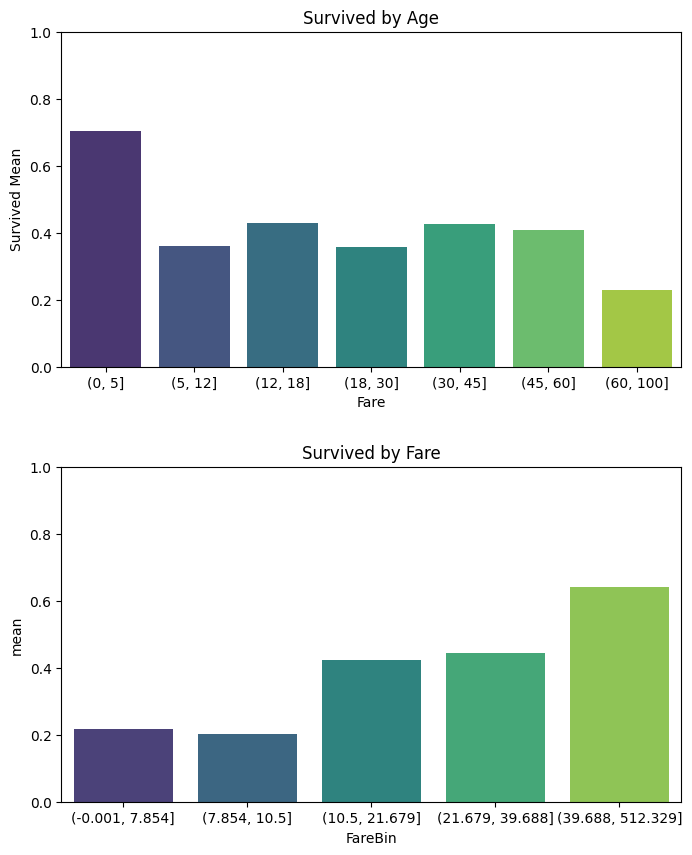

In [9]:
# 수치형 피쳐 - 타깃 관계 분석
    # Age 0-5, 60-100 구간 생존율 차이를 보임
    # Fare가 높을 수록 생존율이 높음 
    
# Age
train["AgeBin"] = pd.cut(
    train["Age"],
    bins=[0, 5, 12, 18, 30, 45, 60, 100],
)

display(
    train.groupby("AgeBin", observed=False)["Survived"]
         .agg(["count", "mean", "std"])
)

# Age_na (Age 파생변수)
    # Age의 결측치가 많아, 결측여부를 파생변수(NA=1, NotNA=0)로 설정, 생존율 비교 분석
    # Age_na = 1일 수록 생존율 낮아짐 (약 -12%p), 결측 자체가 생존과 관련된 변수일 가능성
    # 또한 Age 결측치로 인한 정보 손실을 보완하기 위해 파생변수로 결정 

train["Age_na"] = \
    train["Age"].isna().astype(int)
    
age_na_survived = train.groupby("Age_na")["Survived"]\
    .agg(["count", "mean"])
    
display(age_na_survived)


# Fare
train["FareBin"] = pd.qcut(
    train["Fare"],
    q=5,
    duplicates="drop"
)

display(
    train.groupby("FareBin")["Survived"]
    .agg(["count", "mean", "std"])
)

# 시각화
age_plot = \
    train.groupby(
    "AgeBin", dropna=True
)["Survived"].agg(["mean"]).reset_index()
age_plot["AgeBin"] = age_plot["AgeBin"].astype(str)

fare_plot = \
    train.groupby(
        "FareBin"
    )["Survived"].agg(["mean"]).reset_index()
fare_plot["FareBin"] = fare_plot["FareBin"].astype(str)
    

fig, axs = plt.subplots(2, 1, figsize=(8, 10))
sns.barplot(
    data = age_plot,
    x="AgeBin",
    y="mean", 
    ax=axs[0],
    palette="viridis"
)
axs[0].set_title("Survived by Age")
axs[0].set_xlabel("Age")
axs[0].set_ylabel("Survived Mean")
axs[0].set_ylim(0, 1)
sns.barplot(
    data=fare_plot,
    x="FareBin",
    y="mean",
    ax=axs[1],
    palette="viridis"
)
axs[1].set_title("Survived by Fare")
axs[0].set_xlabel("Fare")
axs[0].set_ylabel("Survived Mean")
axs[1].set_ylim(0, 1)
plt.subplots_adjust(hspace=0.3)
plt.show()



# 1차 피쳐 선택
: 불필요한 원본 칼럼, 파생 변수 칼럼 삭제

In [10]:
# Cabin의 경우 구조가 복잡, 결측치가 너무 많아 제외 결정. 대신 파생변수 Cabin_na, CabinFirstLetter로 대체
feature_cols = [
    # 기본 변수
    "Pclass",
    "Sex",
    "Age",
    "Fare",
    "Embarked",

    # Age 파생
    "Age_na",
    
    # Age/Fare 구간화 변수
    "AgeBin",
    "FareBin",

    # 가족 파생 변수
    "Fam",
    "Alone",

    # Cabin 파생
    "Cabin_na",
    "CabinFirstLetter",

    # Name 파생
    "Title",
    "NameLength",
    "NameLengthBin",

    # Ticket 파생
    "TicketDigitFirst",
    "TicketOnlyAlpha",
]

# 입력 출력 데이터 결정
X = train[feature_cols].copy()
y = train["Survived"].copy()

In [11]:
# 

# 데이터 전처리
: 결측값, 이상값, 중복값 preprocessing

- `Age`는 `Title`, `Pclass`, `Fam`과 관련성이 있는 것으로 확인됨
- 특히 `Title`별 Age 차이가 뚜렷해 결측치 대체의 주요 기준으로 활용함

- `Age_na`를 생성한 뒤, `Title`, `Pclass`, `FamGroup` 기준 중앙값으로 `Age` 결측치를 대체함
- 남은 결측치는 더 넓은 그룹 기준 또는 전체 중앙값으로 보완하고, 이후 `AgeBin`을 재생성함

na_summary


,count,ratio
Age,177,0.198653
AgeBin,177,0.198653
TicketDigitFirst,4,0.004489
Embarked,2,0.002245
Pclass,0,0.000000
Fare,0,0.000000
Age_na,0,0.000000
FareBin,0,0.000000
Sex,0,0.000000
Fam,0,0.000000


[Age_na X Categorical Feature Comparison]
['Embarked X Age']


,count,mean,median,std
Embarked,,,,
C,130,30.814769,29.0,15.434860
Q,28,28.089286,27.0,16.915396
S,554,29.445397,28.0,14.143192


----------------------------------------------------------------------------------------------------
['Pclass X Age']


...

,count,mean,median,std
Title,,,,
Master,36,4.574167,3.5,3.619872
Miss,149,21.845638,21.0,12.870542
Mr,398,32.368090,30.0,12.708793
Mrs,109,35.788991,35.0,11.437490
Rare,22,45.545455,48.5,11.782664


----------------------------------------------------------------------------------------------------
['Cabin_na X Age']


,count,mean,median,std
Cabin_na,,,,
0,185,35.829297,36.0,15.679356
1,529,27.555293,26.0,13.472634


----------------------------------------------------------------------------------------------------
[Age X Numeric Feature Comparison]


Age           1.000000
Fare          0.096067
NameLength    0.034612
Fam          -0.301914
Pclass       -0.369226
Name: Age, dtype: float64

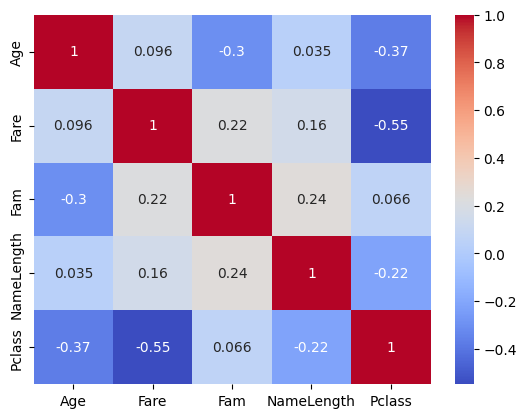

In [12]:
# 결측치 확인
    # Cabin, Age에서 결측치 다수 확인(687, 177)되었으며 원본 결측 유래 일부 파생변수와 Embarked에서 소수 확인
    # Age_na=1의 생존율은 약 29.4%, Age_na=0은 약 40.6%로 차이가 있어 결측 여부 자체가 정보일 가능성이 있음
    # 수치형 상관분석 결과, Age는 Pclass와 음의 상관관계(-0.37), Fam과 음의 상관관계(-0.30)를 보임
    # Fare, NameLength와 Age의 상관성은 낮아 Age 대체 기준으로는 우선순위가 낮음
    # 범주형 분석 결과, Title별 Age 차이가 가장 뚜렷하며 Master < Miss < Mr < Mrs < Rare 순으로 Age가 높아짐
    # Pclass는 등급이 높을수록 Age가 높고, Alone=1일 때 Age가 더 높은 경향을 보임
    # Embarked, Sex는 Age 차이가 크지 않아 대체 기준으로는 우선순위가 낮음
    # Cabin_na=0, 즉 Cabin 정보가 있는 집단의 Age가 더 높지만, Pclass와 중복 정보일 가능성이 있음

na_count = X.isna().sum(axis=0)
na_ratio = X.isna().mean(axis=0)
na_summary = \
    pd.DataFrame(
        {
            "count": na_count,
            "ratio": na_ratio
        }
    ).sort_values(
        by="ratio",
        ascending=False
    )
print('na_summary')
display(na_summary)
print('='*100)

# 비교 칼럼 설정
na_cat_cols = ["Embarked", "Pclass", "Sex", "Alone", "Title", "Cabin_na"]
na_num_cols = ["Age", "Fare", "Fam", "NameLength"]

    # 범주형 칼럼 비교
    
print("[Age_na X Categorical Feature Comparison]")
    
for cat in na_cat_cols:
    print([f"{cat} X Age"])
    
    display(
        X.groupby(cat)["Age"]
        .agg(["count", "mean", "median", "std"])
    )
    
    print('-'*100)

    # 수치형 + 일부 순서형 칼럼 비교
print("[Age X Numeric Feature Comparison]")
num_corr = X[na_num_cols + ["Pclass"]]\
    .corr()["Age"]\
    .sort_values(ascending=False)

display(
    num_corr
)

sns.heatmap(
    X[na_num_cols + ["Pclass"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()




In [13]:
# 결측치 처리
    # Embarked 결측치는 소수이므로 단순 최빈값 대체
X["Embarked"] = \
    X["Embarked"].fillna(X["Embarked"].mode()[0])
print(f"Embarekd_na: {X["Embarked"].isna().sum()}")

print("-"*100)

    #TicketDigitFirst는 소수이면서 알 수 없는 데이터 자료이므로 Other로 대체
X["TicketDigitFirst"] = \
    X["TicketDigitFirst"].fillna("Other")
print(X["TicketDigitFirst"].value_counts())
print(f"TicktDigitFirst_na: {X["TicketDigitFirst"].isna().sum()}")

print("-"*100)

    # Age는 높은 상관성을 보인 Title, Pclass, Fam 그룹별 중앙값으로 대체. 단, Fam은 그룹이 과하게 분리될 수 있어 FamGroup으로 묶음 
X["FamGroup"] = pd.cut(
    X["Fam"],
    bins=[0, 1, 4, 20],
    labels=["Alone", "Small", "Large"]
)
X["Age"] = X["Age"].fillna(
    X.groupby(["Title", "Pclass", "FamGroup"], observed=False)["Age"]
         .transform("median")
)
print(f"Age_na: {X["Age"].isna().sum()}")

print("-"*100)

    #AgeBin 재생성
X["AgeBin"] = pd.cut(
    X["Age"],
    bins=[0, 5, 12, 18, 30, 45, 60, 100]
)

    # 총 결측치 확인
        # 결측 없음
X.isna().sum()

Embarekd_na: 0
----------------------------------------------------------------------------------------------------
TicketDigitFirst
3        355
2        242
1        231
Other     63
Name: count, dtype: int64
TicktDigitFirst_na: 0
----------------------------------------------------------------------------------------------------
Age_na: 0
----------------------------------------------------------------------------------------------------


Pclass              0
Sex                 0
Age                 0
Fare                0
Embarked            0
Age_na              0
AgeBin              0
FareBin             0
Fam                 0
Alone               0
Cabin_na            0
CabinFirstLetter    0
Title               0
NameLength          0
NameLengthBin       0
TicketDigitFirst    0
TicketOnlyAlpha     0
FamGroup            0
dtype: int64

[Outlier Check]


,Age,Fare,Fam
count,891.000000,891.000000,891.000000
mean,29.267306,32.204208,1.904602
std,13.763694,49.693429,1.613459
min,0.420000,0.000000,1.000000
25%,21.000000,7.910400,1.000000
50%,27.000000,14.454200,1.000000
75%,37.000000,31.000000,2.000000
max,80.000000,512.329200,11.000000


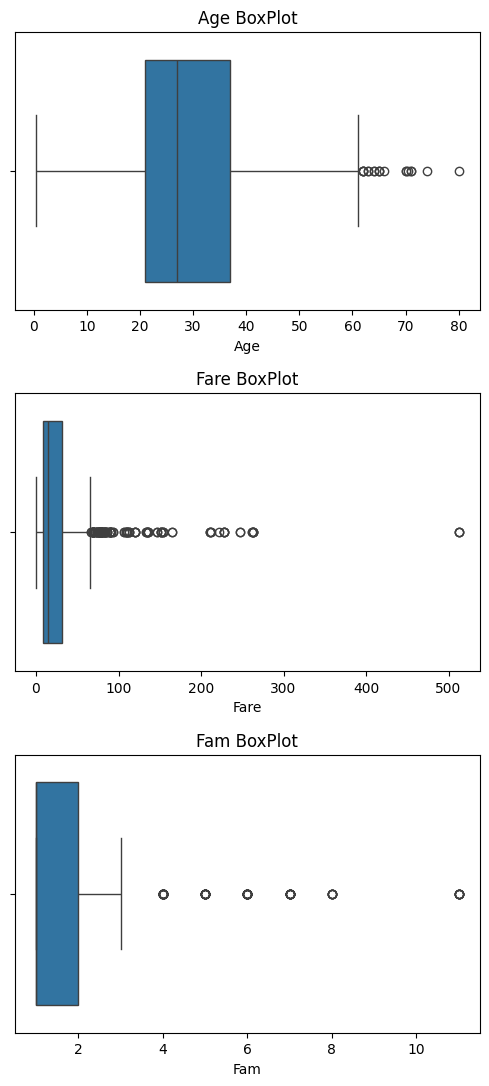

[Duplicated check]
X dup: 16


,Pclass,Sex,Age,Embarked,Age_na,AgeBin,FareBin,Fam,Alone,Cabin_na,CabinFirstLetter,Title,NameLength,NameLengthBin,TicketDigitFirst,TicketOnlyAlpha,FamGroup,FareLog
196,3,male,27.0,Q,1,"(18, 30]","(-0.001, 7.854]",1,1,1,Missing,Mr,19,"(11.999, 19.0]",3,Digit,Alone,2.169054
410,3,male,27.0,S,1,"(18, 30]","(7.854, 10.5]",1,1,1,Missing,Mr,18,"(11.999, 19.0]",3,Digit,Alone,2.185579
531,3,male,27.0,C,1,"(18, 30]","(-0.001, 7.854]",1,1,1,Missing,Mr,17,"(11.999, 19.0]",2,Digit,Alone,2.107689
563,3,male,27.0,S,1,"(18, 30]","(7.854, 10.5]",1,1,1,Missing,Mr,17,"(11.999, 19.0]",3,SOTON,Alone,2.202765
598,3,male,27.0,C,1,"(18, 30]","(-0.001, 7.854]",1,1,1,Missing,Mr,17,"(11.999, 19.0]",2,Digit,Alone,2.107178
601,3,male,27.0,S,1,"(18, 30]","(7.854, 10.5]",1,1,1,Missing,Mr,20,"(19.0, 23.0]",3,Digit,Alone,2.185579
613,3,male,27.0,Q,1,"(18, 30]","(-0.001, 7.854]",1,1,1,Missing,Mr,16,"(11.999, 19.0]",3,Digit,Alone,2.169054
650,3,male,27.0,S,1,"(18, 30]","(7.854, 10.5]",1,1,1,Missing,Mr,17,"(11.999, 19.0]",3,Digit,Alone,2.185579
734,2,male,23.0,S,0,"(18, 30]","(10.5, 21.679]",1,1,1,Missing,Mr,28,"(27.0, 32.0]",2,Digit,Alone,2.639057
738,3,male,27.0,S,1,"(18, 30]","(7.854, 10.5]",1,1,1,Missing,Mr,18,"(11.999, 19.0]",3,Digit,Alone,2.185579


In [14]:
# 이상치 처리
# 수치형 칼럼 간의 단위차이가 크므로 로지스틱 회귀 실험시 표준화가 필요함
# Age 60 이상이 이상치처럼 보이지만, 실제 가능한 나이므로 삭제/대체할 필요는 낮음
# Fare 중앙값(14.45)과 평균(32.20)의 차이가 크다. 표준편차 역시 49로 평균 대비 큰 수치다. 소수의 Fare가 평균을 견인하고 있으며 오른쪽으로 꼬리가 긴 형태.
# Fam 그룹 개수가 많지 않은 준 범주형이므로 이상치 처리 필요성이 낮으며 FamGroup을 활용하는 방향이 적절 
# 이상치 처리는 Fare 중심으로 수행, log 변환을 통해 단위 편차를 줄임 

    # 이상치 확인
out_col = ["Age", "Fare", "Fam"]

print("[Outlier Check]")

display(
    X[out_col].describe()
)

fig, axs = plt.subplots(3, figsize=(6, 13))
plt.subplots_adjust(hspace=0.3)
for i in range(len(out_col)):
    sns.boxplot(
        data=X,
        x=out_col[i],
        ax=axs[i]
    )
    
    axs[i].set_title(
        f"{out_col[i]} BoxPlot"
    )
plt.show()

print("="*100)


    # 이상치 처리
    # Fare 로그 사용
X["FareLog"] = np.log1p(X["Fare"])
X = X.drop(columns="Fare")

# 중복값 확인
    # X 중복값은 16개로 확인됨
    # 원본 Train에서는 중복치 발견되지 않음
    # 중복은 파생변수 생성으로 인한 일부 데이터 간의 우연한 중복일 가능성 높음
    # 따라서 별도의 중복치 처리는 하지 않음
print("[Duplicated check]")

# 입력 데이터 중복값확인
print(f"X dup: {X.duplicated().sum()}")
display(X[X.duplicated()])

# 원본 데이터 중복값 확인
#print(f"orgn dup: {train.duplicated().sum()}")

# 최종 피쳐 선택

- 최초에 Ticket과 Name 파생 변수 다수 포함
- 표본 수가 적을 때 희소 파생 변수 포함시 일반화 성능이 떨어질 수 있다는 피드백 반영
- 중복되는 칼럼을 최소화 하는 방향에서 타깃 변수와 연관성이 큰 변수 위주로 재구성

In [15]:
# Ticket 파생변수는 희소 변수로 그룹 별 표본수가 너무 적음
# NameLength는 타깃과 연관성 있어 보이나, 다른 변수와의 중복 가능성 때문에 제외

X = X[["Pclass", "Sex", "AgeBin", "FareBin", "Embarked", "Title", "FamGroup", "Cabin_na", "Age_na"]]
y = train["Survived"]
print(X.columns)

Index(['Pclass', 'Sex', 'AgeBin', 'FareBin', 'Embarked', 'Title', 'FamGroup',
       'Cabin_na', 'Age_na'],
      dtype='object')


# 범주형 피쳐 인코딩
- 표본 수 적은 관계로 drop_first = True로 설정

In [16]:


cat_cols =  [
    "Embarked", "Title", "FamGroup", "Pclass", "Sex"
]

X_encoded = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=False
)

# train set / validation set 분리

In [17]:
# 훈련/검증셋 분리
splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 훈련/검증셋 확인
print(X_train.shape, y_train.shape, y_train.mean())
print(X_valid.shape, y_valid.shape, y_valid.mean())

(712, 20) (712,) 0.38342696629213485
(179, 20) (179,) 0.3854748603351955


# 수치형 피쳐 표준화

In [18]:
ss = StandardScaler()
scale_cols = [x for x in X_train.columns if (X_train[x].nunique()>=20)]
print(f"scale columns check: {scale_cols}")

# 훈련셋 기준 표준화
X_train[scale_cols] = ss.fit_transform(X_train[scale_cols])

# 검증셋 표준화
X_valid[scale_cols] = ss.transform(X_valid[scale_cols])

display(
    pd.concat(
    [X_train[scale_cols].head(20),
    X_valid[scale_cols].head(20)],
    axis=0
    )
)

scale columns check: []


ValueError: at least one array or dtype is required

# Baseline과 모델별 성능 비교
- baseline과 목표값 설정 
- 10개의 분류 모델 성능 비교
- 성능 안정적이고 높은 모델 결정


#### 분석결과
- ExtraTrees, HistGradientBoosting, XGBoost의 성능이 0.83 안팤으로 가장 높았음
- test_std 또한 0.01-0.02대로 비교적 안정적 성능
- 테스트 성능과 성능 편차를 종합적으로 고려하여 위 세 개의 모델을 테스트와 튜닝


In [ ]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        C=0.5,
        penalty="l2",
        solver="lbfgs",
        random_state=42
    ),

    "DecisionTree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=4,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.03,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=4,
        subsample=0.8,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.03,
        max_leaf_nodes=15,
        min_samples_leaf=10,
        l2_regularization=0.1,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=200,
        learning_rate=0.03,
        random_state=42
    ),

    "SVC": SVC(
        C=0.7,
        kernel="rbf",
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=9,
        weights="distance",
        p=2
    ),

    "GaussianNB": GaussianNB(),

    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
    )
}

In [ ]:
# baseline 점수
    # 모두 비생존으로 예측시 정답률을 baseline으로 잡음
    # baseline 결과 약 0.61의 정답률
    # Survived 타깃과 가장 연관성 높은 Sex 변수에서 female=1, male=0으로 예측한 정답률을 보조 baseline으로 설정.
    # Sex 기반 예측 정답률은 0.78로 비교적 높은 정답률
base_line = (1 - np.round(train["Survived"].mean(), 6))
print(f"baseline: {base_line}")

sex_pred = (train["Sex"] == 'female').astype(int)
sex_acc = accuracy_score(train["Survived"], sex_pred)
print(f"sex_acc: {sex_acc}")

splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# 모델별 성능 비교
    # ExtraTrees, HistGradientBoosting, XGBoost의 성능이 0.83 안팤으로 가장 높았음
    # test_std 또한 0.01-0.02대로 비교적 안정적 성능
    # 테스트 성능과 성능 편차를 종합적으로 고려하여 위 세 개의 모델을 테스트와 튜닝
train_result = []
for name, model in models.items():
    cv_result = cross_validate(
        estimator=model,
        X = X_train,
        y = y_train,
        scoring="accuracy",
        cv = splitter,
        return_train_score=True
    )
    
    train_result.append(
        {"model": name,
         "train_mean": cv_result["train_score"].mean(),
         "test_mean": cv_result["test_score"].mean(),
         "train_std": cv_result["train_score"].std(),
         "test_std": cv_result["test_score"].std()}
    )

model_summary = \
pd.DataFrame(train_result)\
    .sort_values("test_mean", ascending=False).reset_index(drop=True)
    
display(model_summary)

# Logis은ticRegression, RandomForest, ExtraTrees, HistGradientBoosting의 성능이 0.83 안팤으로 높았음
    # 선형 회귀 모델의 성능이 높았다는 점 예상 밖의 결과.
    # 테이블 특성상 비선형 모델이 적합할 것으로 예상했으나, 파생변수 생성, 원본 변수 제거, 전처리 등의 결과로 데이터의 비선형성이 일부 제거된 것으로 보임
    # 최종적으로 LogisticRegression과 RandomForest를 중심으로 튜닝 결정
    
# 분석결과
    # ExtraTrees, HistGradientBoosting, XGBoost의 성능이 0.83 안팤으로 가장 높았음
    # test_std 또한 0.01-0.02대로 비교적 안정적 성능
    # 테스트 성능과 성능 편차를 종합적으로 고려하여 위 세 개의 모델을 테스트와 튜닝

baseline: 0.616162
sex_acc: 0.7867564534231201


,model,train_mean,test_mean,train_std,test_std
0,ExtraTrees,0.836729,0.832897,0.005839,0.026991
1,HistGradientBoosting,0.928370,0.832887,0.004511,0.017177
2,XGBoost,0.893262,0.832877,0.007257,0.016063
3,SVC,0.832867,0.831488,0.005421,0.021078
4,RandomForest,0.838133,0.831488,0.005440,0.024556
5,LogisticRegression,0.834271,0.828671,0.004729,0.025283
6,GradientBoosting,0.903445,0.825845,0.007954,0.012826
7,GaussianNB,0.824091,0.821649,0.008403,0.025277
8,KNN,0.988763,0.813228,0.002859,0.013376
9,DecisionTree,0.843747,0.811819,0.005420,0.031479


# HyperParameter 튜닝

- GridSearchCV로 하이퍼파라미터 튜닝 수행

In [ ]:
# ExtraTrees
    # 튜닝 후 성능 소폭 상승(0.0001)
splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,  
    random_state=42,
)

et_model = ExtraTreesClassifier(random_state=42)


et_params = {
    "n_estimators": [300, 500],
    "max_depth": [3, 4, 5],
    "min_samples_split": [5, 15],
    "min_samples_leaf": [3, 5],
    "max_features": ["sqrt", 0.7]
}

et_gs = GridSearchCV(
    estimator=et_model,
    param_grid=et_params,
    scoring=["accuracy", "f1", "precision", "recall"],
    refit="accuracy",
)

et_gs.fit(
    X_train,
    y_train
)

print(et_gs.best_params_)
print(et_gs.best_score_)


{'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 300}
0.8329262287008765


In [ ]:
# HistGradientBoosting
    # 튜닝 후 성능 저하 (0.002)
hg_model = HistGradientBoostingClassifier(
    random_state=42
)

hg_params = {
    "max_iter": [150, 250],
    "learning_rate": [0.03, 0.05],
    "max_leaf_nodes": [7, 15],
    "min_samples_leaf": [10, 20],
    "l2_regularization": [0.0, 0.1]
}

hg_gs = GridSearchCV(
    estimator=hg_model,
    param_grid=hg_params,
    scoring=["accuracy", "f1", "precision", "recall"],
    refit="accuracy",
)

hg_gs.fit(X_train, y_train)

print(hg_gs.best_params_)
print(hg_gs.best_score_)

{'l2_regularization': 0.0, 'learning_rate': 0.05, 'max_iter': 250, 'max_leaf_nodes': 7, 'min_samples_leaf': 20}
0.8301093272924259


In [ ]:
# XGBoost
    # 튜닝 후 성능저하(0.005)
xg_model = XGBClassifier(
    random_state=42
)

xg_params = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [2, 3],
    "min_child_weight": [2, 4],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_lambda": [1, 3],
    "reg_alpha": [0]
}

xg_gs = GridSearchCV(
    estimator=xg_model,
    param_grid=xg_params,
    scoring=["accuracy", "f1", "precision", "recall"],
    refit="accuracy",
)

xg_gs.fit(X_train, y_train)

print(xg_gs.best_params_)
print(xg_gs.best_score_)

{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 300, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 0.8}
0.8272924258839751


# 1차 모델 성능 비교
- LogisticRegresssion vs RandomForest모델 accuracy를 비교함
    - K-Fold(k=5) 교차 검증 결과 RandomForest의 accuracy가 소폭 높음(0.001)

In [ ]:
model_compare_result = pd.DataFrame([
    {
        "model": "ExtraTrees",
        "best_accuracy": et_gs.cv_results_["mean_test_accuracy"][et_gs.best_index_],
        "best_precision": et_gs.cv_results_["mean_test_precision"][et_gs.best_index_],
        "best_recall": et_gs.cv_results_["mean_test_recall"][et_gs.best_index_],
        "best_f1": et_gs.cv_results_["mean_test_f1"][et_gs.best_index_]
    },
    {
        "model": "HGBC",
        "best_accuracy": hg_gs.cv_results_["mean_test_accuracy"][hg_gs.best_index_],
        "best_precision": hg_gs.cv_results_["mean_test_precision"][hg_gs.best_index_],
        "best_recall": hg_gs.cv_results_["mean_test_recall"][hg_gs.best_index_],
        "best_f1": hg_gs.cv_results_["mean_test_f1"][hg_gs.best_index_],
    },
    {
        "model": "XGC",
        "best_accuracy": xg_gs.cv_results_["mean_test_accuracy"][xg_gs.best_index_],
        "best_precision": xg_gs.cv_results_["mean_test_precision"][xg_gs.best_index_],
        "best_recall": xg_gs.cv_results_["mean_test_recall"][xg_gs.best_index_],
        "best_f1": xg_gs.cv_results_["mean_test_f1"][xg_gs.best_index_],
    }
])

display(model_compare_result)

,model,best_accuracy,best_precision,best_recall,best_f1
0,ExtraTrees,0.832926,0.813835,0.732795,0.769723
1,HGBC,0.830109,0.822183,0.710842,0.761048
2,XGC,0.827292,0.790786,0.747340,0.767993


# 실험 모델 설계
: 타이타닉 호의 구조 당시 상황을 반영한 파생변수 추가 생성 후 실험, 기존 모델과 성능 비교


- 타이타닉: 여성+아이 1순위, 남성은 후순위 / 1*2등석 승객이 3등석 승객보다 많이 구조됨
    - 여성or아이+1*2등석 = 0, 여성or아이+3등석 = 1, 남성+1*2등석=2, 남성+3등석=3으로 코딩
    - ResuePriority로 파생변수 생성 후 실험용 모델 학습

In [ ]:
# 실험 파생 변수 생성
def make_rescue_priority(row):
    if (row["Sex"]=='female') or  (row["Age"] <= 10) or (row["Title"] in ["Mrs", "Miss", "Master"]):
            if row["Pclass"] in [1, 2]:
                return 0
            else:
                return 1
    
    else:
        if row["Pclass"] in [1, 2]:
            return 2
        else:
            return 3

X_exp = X.copy()

X_exp["RescuePriority"] = X_exp.apply(make_rescue_priority, axis=1)

y_exp = y.copy()


display(
    X_exp["RescuePriority"].value_counts()
)


# 원핫인코딩
encode_cols = [
    "Sex", "Embarked", "Title", "FamGroup"
]

X_exp_encoded = pd.get_dummies(X_exp, columns=encode_cols, drop_first=False)
print(X_exp_encoded.columns)


# 훈련/검증 셋 분리
X_train_exp, X_valid_exp, y_train_exp, y_valid_exp = train_test_split(
    X_exp_encoded,
    y_exp, 
    test_size = 0.2,
    random_state=42,
    stratify = y,
    shuffle=True
)

print(X_train_exp.shape, X_valid_exp.shape)
print(y_train_exp.shape, y_valid_exp.shape)

# 스케일링
ss_exp = StandardScaler()
scale_exp_cols = ['Age','FareLog']
X_train_exp[scale_exp_cols] = ss_exp.fit_transform(X_train_exp[scale_exp_cols])
X_valid_exp[scale_exp_cols] = ss_exp.transform(X_valid_exp[scale_exp_cols])
display(X_train_exp[scale_exp_cols])

RescuePriority
3    319
2    218
0    182
1    172
Name: count, dtype: int64

Index(['Pclass', 'Age', 'FareLog', 'Fam', 'Alone', 'Cabin_na', 'Age_na',
       'RescuePriority', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Rare', 'FamGroup_Alone', 'FamGroup_Small', 'FamGroup_Large'],
      dtype='object')
(712, 21) (179, 21)
(712,) (179,)


,Age,FareLog
692,-0.180104,1.124592
481,0.037929,-3.014278
527,1.128096,2.508198
855,-0.834204,-0.627019
801,0.110607,0.361872
...,...,...
359,-0.543493,-0.783592
258,0.401318,3.360891
736,1.346130,0.628438
462,1.273452,0.741106


# 실험 모델 Cross Validation
- 성능 우수한 3 모델(ExtraTrees, HGBC, XGBC)로 평가
- 이후 실험 모델 파라미터 튜닝
- valid set으로 기존 모델과 함께 성능 비교 
#### 분석결과
- ExtraTreesExp의 accuracy=0.8268로 실험변수 추가 전보다 약 0.005의 성능 개선을 소폭 이룸
- HGBC에서는 일부 과적합 경향을 보임.
- XGBC에서는 실험 변수가 성능을 떨어뜨렸으며, 많은 중복 변수 생성이 성능 저하를 일으킬 수 있음을 확인함.

0	ExtraTreesExp	0.826816


1	ExtraTrees	0.821229


2	HGBCExp	0.821229


3	HGBC	0.804469


4	XGBC	0.804469


5	XGBCExp	0.793296


In [ ]:
# 실험 모델 별 성능 교차 검증 테스트
et_exp = et_gs.best_estimator_
hg_exp = hg_gs.best_estimator_
xg_exp = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        random_state=42,
        n_jobs=-1
)

exp_results = []

for name, model in {
    "ExtraTrees_exp": et_exp,
    "HGBC_exp": hg_exp,
    "XGBC_exp": xg_exp
}.items():
    
    cv_exp = cross_validate(
        estimator = model,
        X=X_train_exp,
        y=y_train_exp,
        scoring="accuracy",
        return_train_score=True,
        cv=splitter
    )
    
    exp_results.append({
        "model": name,
        "train_mean": cv_exp["train_score"].mean(),
        "test_mean": cv_exp["test_score"].mean(),
        "train_std": cv_exp["train_score"].std(),
        "test_std": cv_exp["test_score"].std()}
    )
    
model_exp_summary = pd.DataFrame(exp_results)\
    .sort_values("test_mean", ascending=False)

display(model_exp_summary)

,model,train_mean,test_mean,train_std,test_std
0,ExtraTrees_exp,0.837783,0.835704,0.006179,0.028170
1,HGBC_exp,0.911873,0.831498,0.006995,0.033313
2,XGBC_exp,0.889399,0.827253,0.005709,0.027140


In [ ]:
# 테스트 모델 튜닝

et_gs_exp = GridSearchCV(
    estimator=et_exp,
    param_grid = et_params,
    scoring = 'accuracy',
    cv=splitter,
)

hg_gs_exp = GridSearchCV(
    estimator=hg_exp,
    param_grid = hg_params,
    scoring = 'accuracy',
    cv=splitter,
)

xg_gs_exp = GridSearchCV(
    estimator=xg_exp,
    param_grid = xg_params,
    scoring = 'accuracy',
    cv=splitter,
)

et_gs_exp.fit(X_train_exp, y_train_exp)
hg_gs_exp.fit(X_train_exp, y_train_exp)
xg_gs_exp.fit(X_train_exp, y_train_exp)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8], 'learning_rate': [0.03, 0.05], 'max_depth': [2, 3], 'min_child_weight': [2, 4], ...}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [ ]:
# 1차 모델 vs 실험 모델 성능 비교

# 1차 모델 
    # ExtraTrees
et_fin = et_gs.best_estimator_
    # HGBC
hg_fin = hg_gs.best_estimator_
    # XGBC
xg_fin = xg_gs.best_estimator_

# 실험 모델
    # ExtraTrees
et_fin_exp = et_gs_exp.best_estimator_
    # HGBC
hg_fin_exp = hg_gs_exp.best_estimator_
    # XGBC
xg_fin_exp = xg_gs_exp.best_estimator_

model_fin_list = []

for name, model in {
    "ExtraTrees": et_fin,
    "HGBC": hg_fin,
    "XGBC": xg_fin,
    "ExtraTreesExp": et_fin_exp,
    "HGBCExp": hg_fin_exp,
    "XGBCExp": xg_fin_exp
}.items():
    if name.endswith("Exp"):
        pred = model.predict(X_valid_exp)
        score = accuracy_score(y_valid_exp, pred)
        model_fin_list.append(
            {"model": name, 
             "accuracy": score}
        )
    else:
        pred = model.predict(X_valid)
        score = accuracy_score(y_valid, pred)
        model_fin_list.append(
            {"model": name,
             "accuracy": score}
        )

model_fin_summary = pd.DataFrame(model_fin_list).sort_values("accuracy", ascending=False).reset_index(drop=True)
display(model_fin_summary)
        

,model,accuracy
0,ExtraTreesExp,0.826816
1,ExtraTrees,0.821229
2,HGBCExp,0.821229
3,HGBC,0.804469
4,XGBC,0.804469
5,XGBCExp,0.793296


# 결론 및 피드백

#### 변수선택 및 파생변수 생성
- EDA를 통해 Sex, Pclass, Title과 생존 간의 연관관계 확인
- Age_na, Cabin_na 변수 결측 여부와 생존 간의 연관관계 확인
- 과적합 방지 위해 수치형 변수는 Bin으로 처리, SibSp와 Parch는 FamGroup으로 통합
- 성별+나이+객실 등급에 따른 구조 우선순위 상황을 반영, RescuePriority 실험 파생 변수 생성

#### 결측치 처리
- Age의 변수 간 관계 고려해 Title, Pclass, Famgroup 기준 중앙값 대체
- Fare과 Pclass 관계 확인을 통해 Pclass 중앙값 대체
- Embarked 결측값 개수 적은 관계로 최빈값 처리


#### 모델 성능 변화
1. 최초에 다수의 파생변수와 함께 실험
    - 비선형 관계를 해소해 LogisticRegression의 accuracy 0.84로 가장 높았음
    - 하지만 test 단계에서 0.77로 과적합 확인
2. 파생 변수 축소, 범주형 변수 그룹 최소화로 실험
    - XGBoost, ExtraTrees의 accurcay 약 0.83으로 가장 높았음
    - 하지만 test 단계에서 0.78로 과적합 확인
3. 2에서 실험 파생 변수 RescuePriority 추가하여 재실험
    - HistGradientBoost와 ExtraTrees의 accurcy 0.85로 이전보다 성능 높음을 확인
    - 하지만 test 단계에서 2의 경우와 큰 차이를 보이지 않음
    - 실험 파생 변수는 train 데이터 분포에는 적합했으나, test에는 영향이 미미함을 확인

#### 피드백
1. 데이터 표본 작을 때 파생변수 개수 조절하기
    - 과적합되어 일반화 성능이 낮아질 수 있음


2. Train/Validation/Test 세트 구별 후 전처리
    - 검증, 테스트 세트의 데이터 유출 가능성
    - 내부 성능 평가에서 train과 valid의 성능 차이는 이것에 기인한 결과일 가능성
    - 테스트 셋에서 성능 좋은 모델 선별에 실패함


3. 결측값 자체가 예측에 유의미한 정보
    - EDA를 통해 일부 피쳐의 결측값이 타깃 변수와 주목할 만한 관계임을 확인함
    - 결측치는 1차적으로 변환 대상이지만, 그 자체로 중요한 정보일 수 있음.


4. 내부 성능 보다는 일반화 성능을 고려할 필요